In [2]:
%pip install kagglehub
%pip install pandas scikit-learn matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [kagglehub]/4 [kagglesdk]

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 38.3 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 64.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 48.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 48.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 53.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 49.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 49.1 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14/14 [seaborn]3/14 [seaborn]ib]n]

[notice] A new release of pip is available: 

In [3]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download("adarshsng/lending-club-loan-data-csv")
csv_path = os.path.join(path, "loan.csv")

# Only load the first 1.4 million rows (out of 2.26 million)
#loan_df = pd.read_csv(csv_path, nrows=1400000)

# retreive all column names
cols = pd.read_csv(csv_path, nrows=0).columns

# column to be dropped, comments are missing percentage
cols_to_drop = ['id',   # 100%
                'member_id',   # 100%
                'url',   # 100%
                'desc',   # 94%
                'mths_since_last_delinq',  # 51%
                'mths_since_last_record',  # 84%
                'next_pymnt_d',   # 58%
                'mths_since_last_major_derog',   # 74%
                'annual_inc_joint',   # 95%
                'dti_joint',   # 95%
                'verification_status_joint',   # 95%
                'open_acc_6m',   # 38%
                'open_act_il',   # 38%
                'open_il_12m',   # 38%
                'open_il_24m',   # 38%
                'mths_since_rcnt_il',   # 40%
                'total_bal_il',   # 38%
                'il_util',   # 47%
                'open_rv_12m',   # 38%
                'open_rv_24m',   # 38%
                'max_bal_bc',   # 38%
                'all_util',   # 38%
                'inq_fi',   # 38%
                'total_cu_tl',   # 38%
                'inq_last_12m',   # 38%
                'mths_since_recent_bc_dlq',  # 77%
                'mths_since_recent_revol_delinq',  # 67%
                'revol_bal_joint',  # 95%
                'sec_app_earliest_cr_line',  # 95%
                'sec_app_inq_last_6mths',   # 95%
                'sec_app_mort_acc',   # 95%
                'sec_app_open_acc',   # 95%
                'sec_app_revol_util',   # 95%
                'sec_app_open_act_il',  # 95%
                'sec_app_num_rev_accts',  # 95%
                'sec_app_chargeoff_within_12_mths',   # 95%
                'sec_app_collections_12_mths_ex_med',   # 95%
                'sec_app_mths_since_last_major_derog',  # 98%
                'hardship_type',   # 100%
                'hardship_reason',  # 100%
                'hardship_status',  # 100%
                'deferral_term',   # 100%
                'hardship_amount',  # 100%
                'hardship_start_date',  # 100%
                'hardship_end_date',   # 100%
                'payment_plan_start_date',   # 100%
                'hardship_length',   # 100%
                'hardship_dpd',  # 100%
                'hardship_loan_status',   # 100%
                'orig_projected_additional_accrued_interest',  # 100%
                'hardship_payoff_balance_amount',   # 100%
                'hardship_last_payment_amount',   # 100%
                'debt_settlement_flag_date',   # 99%
                'settlement_status',   # 99%
                'settlement_date',   # 99%
                'settlement_amount',   # 99%
                'settlement_percentage',   # 99%
                'settlement_term',  # 99%
                
                # Variables irrelevant for default prediction
                'collection_recovery_fee',
                'recoveries',
                'last_credit_pull_d',
                'last_pymnt_amnt',
                'last_pymnt_d',
                'out_prncp',
                'out_prncp_inv',
                'total_pymnt',
                'total_pymnt_inv',
                'total_rec_int',
                'total_rec_late_fee',
                'total_rec_prncp',

                # add more irrelevant columns (by Kasem)
                'policy_code',
                'tot_coll_amt',
                'total_rev_hi_lim',  # correlated with revol_util
                'avg_cur_bal',
                'bc_open_to_buy',
                'mo_sin_old_il_acct',
                'mo_sin_rcnt_rev_tl_op',
                'mo_sin_rcnt_tl',
                'mths_since_recent_inq',
                'num_actv_bc_tl'

                #ashish
                'funded_amnt',      # post-application, leakage
                'funded_amnt_inv',  # post-application, leakage
                'installment',      # derived from loan_amnt + int_rate + term, redundant
                'grade',            # multicollinesrity with sub-grade
                'issue_d',          # will not be available at prediction time
                'pymnt_plan',       # post-default indicator, pure leakage
                'title',            # free-text, redundant with purpose
                'zip_code',         # redundant with addr_state, too granular
                
                #prerna
                'hardship_flag',         # Post-loan hardship event (data leakage)
                'debt_settlement_flag',  # Post-default outcome indicator (data leakage)
                'disbursement_method',   # Operational variable, not related to credit risk
                'num_sats',              # Raw count; percentage version is more informative
                'num_bc_tl',             # Weak standalone signal; redundant with other credit counts
                'num_il_tl',             # Installment count adds little predictive value
                'num_op_rev_tl',         # Highly correlated with other account count variables
                'num_rev_accts',         # Redundant credit depth measure
                'total_bc_limit'         # Redundant with overall credit limit (tot_hi_cred_lim)
                ]

# columns to keep
cols_to_keep = [col for col in cols if col not in cols_to_drop]

# load data
loan_df = pd.read_csv(csv_path, usecols=cols_to_keep)

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 339M/339M [00:02<00:00, 119MB/s]  

Extracting files...


In [4]:
loan_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Data columns (total 50 columns):
 #   Column                      Dtype  
---  ------                      -----  
 0   loan_amnt                   int64  
 1   funded_amnt                 int64  
 2   term                        str    
 3   int_rate                    float64
 4   sub_grade                   str    
 5   emp_title                   str    
 6   emp_length                  str    
 7   home_ownership              str    
 8   annual_inc                  float64
 9   verification_status         str    
 10  loan_status                 str    
 11  purpose                     str    
 12  addr_state                  str    
 13  dti                         float64
 14  delinq_2yrs                 float64
 15  earliest_cr_line            str    
 16  inq_last_6mths              float64
 17  open_acc                    float64
 18  pub_rec                     float64
 19  revol_bal                   int6

In [5]:
# Check for columns with large amount of missing values
missing = loan_df.isnull().sum()
missing = missing[missing > 0]
missing.sort_values(ascending=False)

emp_title                     166969
num_tl_120dpd_2m              153657
emp_length                    146907
bc_util                        76071
percent_bc_gt_75               75379
mths_since_recent_bc           73412
pct_tl_nvr_dlq                 70431
mo_sin_old_rev_tl_op           70277
num_rev_tl_bal_gt_0            70276
num_actv_bc_tl                 70276
num_actv_rev_tl                70276
tot_hi_cred_lim                70276
tot_cur_bal                    70276
num_accts_ever_120_pd          70276
num_tl_op_past_12m             70276
num_tl_90g_dpd_24m             70276
num_tl_30dpd                   70276
total_il_high_credit_limit     70276
num_bc_sats                    58590
mort_acc                       50030
total_bal_ex_mort              50030
acc_open_past_24mths           50030
revol_util                      1802
dti                             1711
pub_rec_bankruptcies            1365
collections_12_mths_ex_med       145
chargeoff_within_12_mths         145
t

In [6]:
# change string cols to categorical type

# list of column names to change to categorical type
to_cat_list = ['application_type']
loan_df[to_cat_list] = loan_df[to_cat_list].astype('category')

In [ ]:
# change cols to numeric dtype
loan_df['term'] = loan_df['term'].str.strip().str.replace(' months', '').astype(int)
emp_length_map = {
    '< 1 year': 0,
    '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8,
    '9 years': 9, '10+ years': 10
}
loan_df['emp_length'] = loan_df['emp_length'].map(emp_length_map)
loan_df['emp_length'] = loan_df['emp_length'].fillna(0)

# Create new binary variable for employment based on employment title
loan_df["Employed"] = loan_df["emp_title"].notna().astype(int)
loan_df["emp_title"] = loan_df["emp_title"].fillna("Unemployed")

np.int64(0)

In [4]:
loan_df["loan_status"].value_counts()

loan_status
Fully Paid                                             1041952
Current                                                 919695
Charged Off                                             261655
Late (31-120 days)                                       21897
In Grace Period                                           8952
Late (16-30 days)                                         3737
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     31
Name: count, dtype: int64

In [5]:
small_null_cols = [col for col in loan_df.columns if 0 < loan_df[col].isnull().sum() <= 2000]
print(small_null_cols)

loan_df = loan_df.dropna(subset=small_null_cols)
print(loan_df.shape) 

['annual_inc', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq', 'chargeoff_within_12_mths', 'delinq_amnt', 'pub_rec_bankruptcies', 'tax_liens']
(2255820, 50)


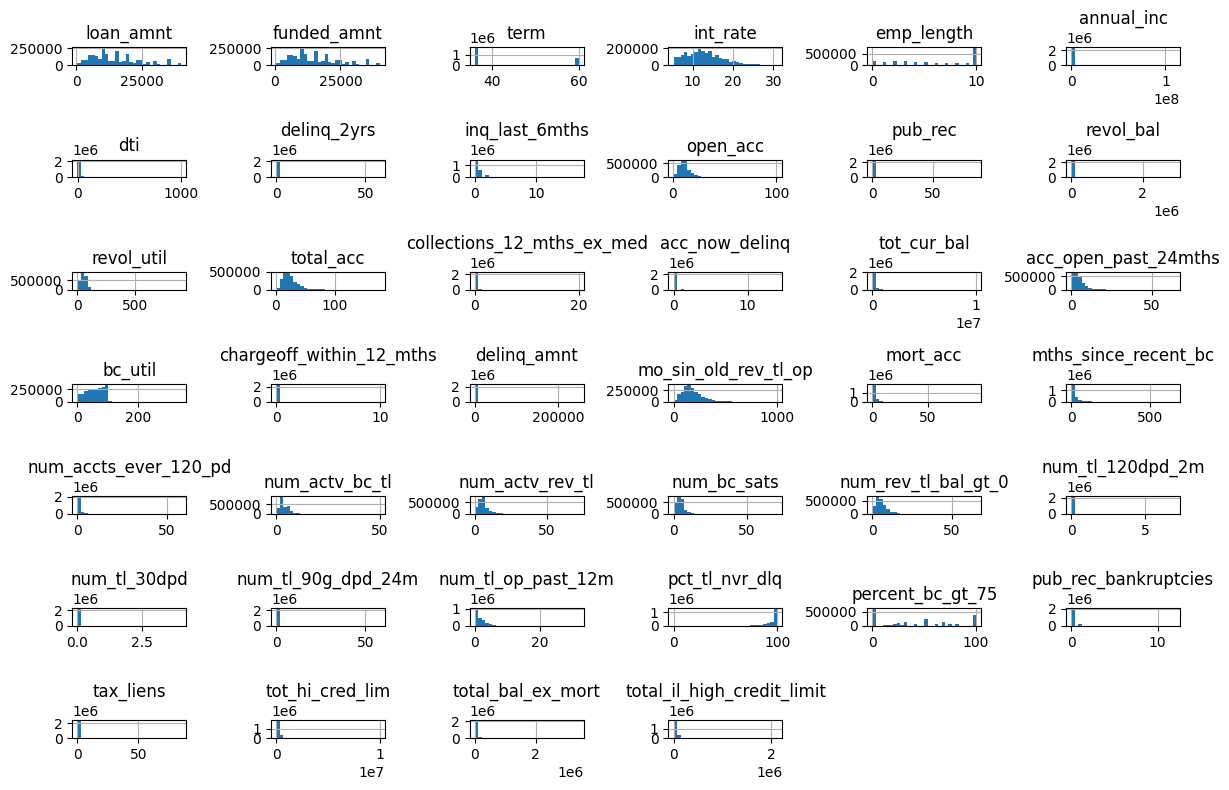

In [ ]:
# plot histogram for all numerical columns

import matplotlib.pyplot as plt

loan_df.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

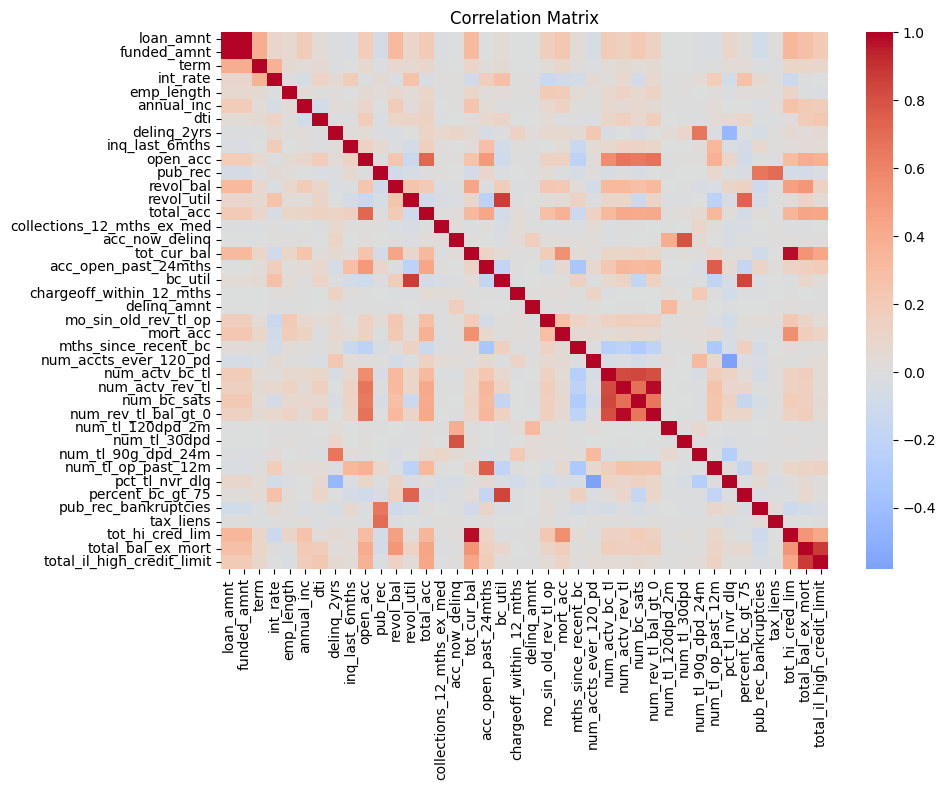

In [ ]:
# heatmap for correlation
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(loan_df.select_dtypes('number').corr(), cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [15]:
# correlation table
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
loan_df.select_dtypes('number').corr()

,loan_amnt,funded_amnt,term,int_rate,emp_length,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,collections_12_mths_ex_med,acc_now_delinq,tot_cur_bal,acc_open_past_24mths,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_rev_tl_op,mort_acc,mths_since_recent_bc,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_rev_tl_bal_gt_0,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_il_high_credit_limit
loan_amnt,1.000000,0.999760,0.393707,0.098187,0.078979,0.197474,0.043339,-0.009180,-0.027218,0.182183,-0.058977,0.317310,0.099134,0.199655,-0.021891,-0.000517,0.310470,-0.000962,0.048399,-0.003787,0.000814,0.165557,0.219145,0.036324,-0.053487,0.191231,0.149117,0.212476,0.148492,-0.001808,0.000915,-0.023502,-0.026831,0.089420,0.020824,-0.083698,0.007516,0.335273,0.276459,0.208666
funded_amnt,0.999760,1.000000,0.393316,0.098205,0.079046,0.197441,0.043540,-0.009075,-0.027485,0.182347,-0.058842,0.317246,0.099190,0.199568,-0.021828,-0.000484,0.310471,-0.000961,0.048394,-0.003742,0.000824,0.165557,0.219145,0.036324,-0.053488,0.191231,0.149118,0.212476,0.148493,-0.001808,0.000915,-0.023503,-0.026832,0.089419,0.020822,-0.083583,0.007587,0.335273,0.276459,0.208665
term,0.393707,0.393316,1.000000,0.372711,0.055210,0.036130,0.058125,-0.009132,-0.000676,0.074688,-0.017659,0.083394,0.067266,0.095760,-0.009940,-0.000038,0.111081,0.026246,0.051414,-0.002230,-0.000897,0.047691,0.102998,0.021005,-0.018773,0.049772,0.055570,0.049460,0.055882,-0.001690,0.000648,-0.011019,0.006933,0.042818,0.047633,-0.011675,-0.009024,0.108622,0.107230,0.091745
int_rate,0.098187,0.098205,0.372711,1.000000,-0.009964,-0.050455,0.124772,0.058817,0.189861,-0.010162,0.053506,-0.028722,0.262559,-0.040800,0.018336,0.015566,-0.085546,0.172428,0.277094,0.014184,0.004854,-0.133578,-0.090003,-0.075505,0.051768,0.020861,0.082859,-0.060868,0.082741,0.006077,0.012771,0.033398,0.182081,-0.079232,0.271852,0.056812,0.013936,-0.123947,0.007090,-0.001588
emp_length,0.078979,0.079046,0.055210,-0.009964,1.000000,0.043925,0.017791,0.022564,-0.000416,0.052963,0.031557,0.087185,0.036901,0.107906,-0.006608,0.008748,0.099965,0.024349,0.032326,0.009555,0.001850,0.208082,0.186714,0.039309,0.009296,0.080181,0.125638,0.071711,0.126634,0.001847,0.008195,-0.001291,0.023874,-0.019850,0.029671,0.024540,0.015421,0.115574,-0.009569,-0.026195
annual_inc,0.197474,0.197441,0.036130,-0.050455,0.043925,1.000000,-0.082741,0.026077,0.020083,0.094280,-0.002640,0.190627,0.028219,0.115015,-0.003524,0.007296,0.253323,0.039939,0.004759,0.004639,0.003832,0.087125,0.134669,0.015624,0.008213,0.076391,0.057021,0.086375,0.056282,0.002752,0.006753,0.003879,0.034147,-0.004835,-0.003194,-0.027160,0.024372,0.264436,0.206997,0.175005
dti,0.043339,0.043540,0.058125,0.124772,0.017791,-0.082741,1.000000,-0.012242,-0.011787,0.186268,-0.026205,0.102500,0.115122,0.147298,-0.007085,-0.000169,0.021360,0.084503,0.117817,-0.003360,-0.003698,0.041188,-0.009563,0.002914,-0.029265,0.110229,0.159217,0.071227,0.161545,-0.003325,0.001232,-0.013378,0.045208,0.065470,0.104021,-0.012457,-0.020587,0.031386,0.194358,0.219885
delinq_2yrs,-0.009180,-0.009075,-0.009132,0.058817,0.022564,0.026077,-0.012242,1.000000,0.024567,0.049175,-0.021810,-0.026702,-0.000190,0.118574,0.071977,0.116008,0.056519,-0.050223,0.002884,0.140040,0.028496,0.078816,0.075226,0.052770,0.218139,-0.037437,-0.000167,-0.030860,-0.004347,0.043986,0.097845,0.656816,-0.022029,-0.442479,-0.000523,-0.049291,0.011375,0.056689,0.028154,0.056490
inq_last_6mths,-0.027218,-0.027485,-0.000676,0.189861,-0.000416,0.020083,-0.011787,0.024567,1.000000,0.139045,0.065507,-0.010297,-0.078902,0.156079,0.011416,-0.001407,0.030595,0.280359,-0.069399,0.011968,0.001511,-0.004278,0.046837,-0.130420,0.049511,0.076959,0.127490,0.123879,0.109307,0.000941,-0.003234,0.030109,0.330340,-0.028355,-0.061976,0.074086,0.013960,0.031

In [21]:
from sklearn.impute import KNNImputer

# Identify numeric and categorical columns
num_cols = loan_df.select_dtypes(include=['number']).columns
cat_cols = loan_df.select_dtypes(include=['object','category','string']).columns

# Convert numeric columns to float32 to reduce memory consumption
loan_df[num_cols] = loan_df[num_cols].astype("float32")

# Since the dataset is very large (~2.2M rows),
# we use a sample of 100,000 rows to train the KNN imputer
sample_df = loan_df[num_cols].sample(100000, random_state=42)

print("Sample used for KNN:", sample_df.shape)

# Initialize the KNN imputer
# n_neighbors=5 means missing values will be estimated using the 5 nearest similar records
imputer = KNNImputer(n_neighbors=5)

# Fit the KNN model and transform the sample data
sample_imputed = imputer.fit_transform(sample_df)

# Convert the imputed result back into a DataFrame
sample_imputed_df = pd.DataFrame(sample_imputed, columns=num_cols)

# Use KNN results to fill full dataset
knn_values = sample_imputed_df.median()

loan_df[num_cols] = loan_df[num_cols].fillna(knn_values)

# Handle categorical columns
for col in cat_cols:
    loan_df[col] = loan_df[col].fillna(loan_df[col].mode()[0])

print("Remaining missing values:", loan_df.isnull().sum().sum())

Sample used for KNN: (100000, 40)
Remaining missing values: 0
